# Semantic Analysis of Works of Fiction
### Master Thesis Prototype
---

## Step 1 — Install Libraries

In [ ]:
!pip install transformers torch scikit-learn spacy bertopic pymupdf matplotlib
!python -m spacy download en_core_web_sm
print("All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 65.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All libraries installed!


## Step 2 — Load Modules

In [ ]:
import spacy
import json
import os
import fitz
import matplotlib.pyplot as plt
import numpy as np
from transformers import pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from bertopic import BERTopic

nlp = spacy.load("en_core_web_sm")
emotion_classifier = pipeline("text-classification",
                               model="j-hartmann/emotion-english-distilroberta-base",
                               top_k=1)

print("All modules loaded successfully!")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

All modules loaded successfully!


## Step 3 — Define All Functions

In [ ]:
def extract_entities(text):
    doc = nlp(text)
    characters = []
    entities = []
    for ent in doc.ents:
        if ent.label_ == "PERSON":
            characters.append(ent.text)
        else:
            entities.append(ent.text)
    return characters, entities

def extract_themes(text):
    keywords = ["conflict", "authority", "resistance", "power", "loyalty",
                "betrayal", "hope", "fear", "responsibility", "moral",
                "tension", "trust", "control", "decision", "freedom"]
    found_themes = [word for word in keywords if word.lower() in text.lower()]
    vectorizer = TfidfVectorizer(max_features=5, stop_words='english')
    try:
        tfidf = vectorizer.fit_transform([text])
        tfidf_themes = vectorizer.get_feature_names_out().tolist()
    except:
        tfidf_themes = []
    all_themes = list(set(found_themes + tfidf_themes))
    return all_themes[:5] if all_themes else ["tension", "conflict"]

def extract_themes_bertopic(text):
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]
    if len(sentences) < 3:
        return extract_themes(text)
    try:
        topic_model = BERTopic(language="english", calculate_probabilities=False, verbose=False)
        topics, _ = topic_model.fit_transform(sentences)
        topic_info = topic_model.get_topic_info()
        keywords = []
        for topic_id in topic_info['Topic'].values:
            if topic_id != -1:
                words = topic_model.get_topic(topic_id)
                if words:
                    keywords.extend([w[0] for w in words[:3]])
        return list(set(keywords))[:5] if keywords else extract_themes(text)
    except Exception:
        return extract_themes(text)

def detect_emotion(text):
    truncated = text[:512]
    result = emotion_classifier(truncated)
    label = result[0][0]['label']
    score = round(result[0][0]['score'], 2)
    return label, score

def detect_narrative_role(text, themes, emotion):
    text_lower = text.lower()
    scores = {
        "exposition": 0,
        "tension building": 0,
        "moral decision point": 0,
        "conflict escalation": 0,
        "turning point": 0,
        "resolution": 0
    }
    if any(w in text_lower for w in ["entered", "arrived", "began", "introduced", "found", "discovered", "once", "years ago", "background"]):
        scores["exposition"] += 2
    if emotion in ["neutral"]:
        scores["exposition"] += 1
    if any(w in text_lower for w in ["waited", "silence", "watching", "slowly", "careful", "uneasy", "nervous", "tense", "wrong", "felt"]):
        scores["tension building"] += 2
    if emotion in ["fear", "neutral"] and any(w in text_lower for w in ["silent", "hum", "waiting"]):
        scores["tension building"] += 2
    if any(w in text_lower for w in ["refused", "decided", "chose", "would not", "should", "must", "if she", "if he", "risk", "orders"]):
        scores["moral decision point"] += 2
    if any(w in themes for w in ["responsibility", "conflict", "decision", "moral", "power"]):
        scores["moral decision point"] += 2
    if any(w in text_lower for w in ["attacked", "fought", "shouted", "slammed", "clash", "confronted", "grabbed", "rushed"]):
        scores["conflict escalation"] += 2
    if emotion in ["anger", "fear"]:
        scores["conflict escalation"] += 1
    if any(w in text_lower for w in ["realized", "understood", "suddenly", "changed", "never", "walked out", "turned", "betrayal"]):
        scores["turning point"] += 2
    if any(w in themes for w in ["betrayal", "discovery", "change"]):
        scores["turning point"] += 2
    if any(w in text_lower for w in ["finally", "ended", "peace", "resolved", "forgave", "accepted", "smiled", "relief"]):
        scores["resolution"] += 2
    if emotion in ["joy", "neutral"] and any(w in text_lower for w in ["end", "last", "finally"]):
        scores["resolution"] += 1
    best_role = max(scores, key=scores.get)
    if scores[best_role] == 0:
        return "narrative development"
    return best_role

def analyze_scene_full(scene_text, mode="zero-shot"):
    print(f"\n{'='*60}")
    print(f"MODE: {mode.upper()}")
    print(f"{'='*60}")
    print(f"INPUT SCENE:\n{scene_text[:200]}...\n")
    doc = nlp(scene_text)
    tokens = [token.text for token in doc if not token.is_stop and not token.is_punct]
    pos_tags = [(token.text, token.pos_) for token in doc if not token.is_stop and not token.is_punct]
    print(f"STEP 1 - PREPROCESSING:")
    print(f"Tokens: {tokens[:10]}...")
    print(f"POS Tags: {pos_tags[:5]}...\n")
    characters, entities = extract_entities(scene_text)
    print(f"STEP 2 - ENTITY EXTRACTION:")
    print(f"Characters: {characters}")
    print(f"Entities: {entities}\n")
    themes = extract_themes_bertopic(scene_text)
    print(f"STEP 3 - THEMATIC ANALYSIS (BERTopic):")
    print(f"Themes/Keywords: {themes}\n")
    emotion, confidence = detect_emotion(scene_text)
    print(f"STEP 4 - EMOTIONAL TONE:")
    print(f"Emotion: {emotion} (confidence: {confidence})\n")
    narrative_role = detect_narrative_role(scene_text, themes, emotion)
    print(f"STEP 5 - NARRATIVE ROLE:")
    print(f"Role: {narrative_role}\n")
    result = {
        "mode": mode,
        "characters": characters,
        "entities": entities,
        "themes": themes,
        "emotion": emotion,
        "confidence": confidence,
        "narrative_role": narrative_role
    }
    print(f"FINAL SEMANTIC INTERPRETATION:")
    for key, value in result.items():
        print(f"  {key}: {value}")
    print(f"{'='*60}\n")
    return result

def split_into_scenes(text, scene_length=500):
    words = text.split()
    scenes = []
    for i in range(0, len(words), scene_length):
        chunk = " ".join(words[i:i+scene_length])
        if len(chunk.strip()) > 100:
            scenes.append({
                "id": f"scene_{i//scene_length + 1:03d}",
                "title": f"Scene {i//scene_length + 1}",
                "text": chunk
            })
    return scenes

def analyze_book(text, max_scenes=3):
    scenes = split_into_scenes(text)
    print(f"Book split into {len(scenes)} scenes")
    print(f"Analyzing first {max_scenes} scenes...\n")
    results = []
    for scene in scenes[:max_scenes]:
        print(f"--- {scene['title']} ---")
        result = analyze_scene_full(scene['text'], mode="zero-shot")
        results.append(result)
    return results

def visualize_analysis(result, title="Semantic Analysis Results"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    emotions = ['fear', 'anger', 'sadness', 'joy', 'neutral', 'surprise', 'disgust']
    values = [0.0] * len(emotions)
    if result['emotion'].lower() in emotions:
        values[emotions.index(result['emotion'].lower())] = result['confidence']
    colors = ['red' if e == result['emotion'].lower() else 'lightgray' for e in emotions]
    axes[0].bar(emotions, values, color=colors)
    axes[0].set_title('Emotional Tone Detection')
    axes[0].set_ylabel('Confidence Score')
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis='x', rotation=45)
    themes = result['themes'][:5] if result['themes'] else ['none']
    theme_scores = np.linspace(0.9, 0.5, len(themes))
    axes[1].barh(themes, theme_scores, color='steelblue')
    axes[1].set_title('Detected Themes')
    axes[1].set_xlabel('Relevance Score')
    axes[1].set_xlim(0, 1)
    layers = ['Characters', 'Entities', 'Themes', 'Emotion', 'Narrative Role']
    completeness = [
        1.0 if result['characters'] else 0,
        1.0 if result['entities'] else 0,
        1.0 if result['themes'] else 0,
        1.0 if result['emotion'] else 0,
        1.0 if result['narrative_role'] else 0
    ]
    colors2 = ['green' if c == 1.0 else 'red' for c in completeness]
    axes[2].bar(layers, completeness, color=colors2)
    axes[2].set_title('Semantic Layers Completeness')
    axes[2].set_ylabel('Detected (1=Yes, 0=No)')
    axes[2].set_ylim(0, 1.2)
    axes[2].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig("analysis_visualization.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved!")

print("All functions defined successfully!")

All functions defined successfully!


## Step 4 — Load Expanded Dataset (10 Scenes)

In [ ]:
# Expanded dataset with 10 diverse fictional scenes
expanded_dataset = {
    "scenes": [
        {"id": "scene_001", "title": "The Control Room", "genre": "sci-fi",
         "text": "Evelyn stood at the center of the control room, her eyes fixed on the blinking red light above the main console. The room was silent except for the hum of machines. Around her, the crew waited. She had been given direct orders to initiate the shutdown sequence, but something felt wrong. The data did not match. If she followed the orders, thousands could be at risk. If she refused, she would be committing an act of insubordination that could end her career. She took a deep breath and reached for the console."},
        {"id": "scene_002", "title": "The Confrontation", "genre": "thriller",
         "text": "Marcus slammed the door behind him. The general sat behind the desk, unmoved. For years Marcus had followed orders without question, sacrificed everything for the cause. But standing here now, the files spread across the table between them, he realized the cause had never been what they told him. Betrayal settled into his bones like cold. He picked up the files slowly, met the general's eyes, and walked out without a word."},
        {"id": "scene_003", "title": "The Discovery", "genre": "drama",
         "text": "Anna found the letter hidden beneath the floorboards, yellowed with age. Her grandmother's handwriting. She had always believed her family had fled the war with nothing but their lives. But the letter spoke of a different story — of choices made, of people left behind, of a secret carried across decades. Anna sat down on the cold floor and began to read, and with every line, the grandmother she thought she knew became a stranger."},
        {"id": "scene_004", "title": "The Last Battle", "genre": "fantasy",
         "text": "The kingdom had fallen. Smoke rose from the towers as Aldric knelt beside the body of his king. Around him, the survivors stood in silence, weapons lowered, too exhausted even for grief. He had sworn an oath to protect the crown, and he had failed. The enemy had not come from outside the walls — it had grown from within, nurtured by those he had trusted. Aldric closed the king's eyes and rose slowly. There was still one thing left to do."},
        {"id": "scene_005", "title": "The Return", "genre": "drama",
         "text": "Sofia stepped off the train and looked at the town she had left fifteen years ago. Nothing had changed — the same cracked pavements, the same bakery on the corner, the same church bell ringing the hour. But she had changed. She was no longer the girl who had run away in the night with nothing but a suitcase and a handful of broken promises. She was here to face what she had left behind. She straightened her coat and walked toward the house at the end of the road."},
        {"id": "scene_006", "title": "The Interrogation", "genre": "thriller",
         "text": "The detective placed the photographs on the table one by one. The suspect said nothing, but his eyes moved. That was enough. Detective Hana had learned long ago that people do not lie with their mouths — they lie with everything else. The hands that stay too still. The breath that comes too fast. She leaned forward and spoke quietly. She did not ask whether he had done it. She asked why. And for one unguarded moment, something crossed his face that was unmistakably close to relief."},
        {"id": "scene_007", "title": "The Farewell", "genre": "romance",
         "text": "They stood on the platform as the last call was announced. Elena had memorised his face a hundred times over the past week, knowing this moment would come. He did not ask her to stay, and she did not ask him to come with her. Some things are understood without words. She picked up her bag and walked toward the gate. She did not look back. Not because she did not want to, but because she knew that if she did, she would not be able to leave."},
        {"id": "scene_008", "title": "The Awakening", "genre": "horror",
         "text": "Daniel woke to silence. The kind of silence that does not feel empty but full — full of something waiting. He lay still and listened. The house settled. The wind moved outside. And then, beneath those ordinary sounds, he heard it again — the thing that had pulled him from sleep. Soft, rhythmic, patient. Coming from the room his daughter had stopped sleeping in three weeks ago. He got up slowly and moved toward the door at the end of the hallway. His hand rested on the handle. He did not turn it."},
        {"id": "scene_009", "title": "The Verdict", "genre": "legal drama",
         "text": "The courtroom was silent as the judge read the verdict. Gabriel sat with his hands folded on the table, his face expressionless. He had spent four years preparing for this moment. He had given up his practice, his marriage, his reputation — everything — to bring this case to court. The words the judge read were not the ones he had fought for. Around him, the family of the victim sat motionless. He looked at them and found he had nothing to say. Justice, he had learned, is not always the same as truth."},
        {"id": "scene_010", "title": "The Choice", "genre": "sci-fi",
         "text": "The signal had been confirmed three times. Dr. Yuna Park stared at the data stream on her screen and understood that everything she had believed about humanity's place in the universe was about to change. She had two options. Report it through official channels, where it would be buried, classified, controlled. Or release it — all of it — to the world tonight. She thought of her daughter. She thought of her colleagues. She thought of the billions of people who would wake up tomorrow to a different world. Her finger hovered over the send button."}
    ]
}

with open("fiction_dataset_expanded.json", "w") as f:
    json.dump(expanded_dataset, f, indent=2)

with open("fiction_dataset_expanded.json", "r") as f:
    dataset = json.load(f)

print(f"Dataset loaded: {len(dataset['scenes'])} scenes")
for s in dataset['scenes']:
    print(f"  {s['id']} — {s['title']} [{s['genre']}]")

Dataset loaded: 10 scenes
  scene_001 — The Control Room [sci-fi]
  scene_002 — The Confrontation [thriller]
  scene_003 — The Discovery [drama]
  scene_004 — The Last Battle [fantasy]
  scene_005 — The Return [drama]
  scene_006 — The Interrogation [thriller]
  scene_007 — The Farewell [romance]
  scene_008 — The Awakening [horror]
  scene_009 — The Verdict [legal drama]
  scene_010 — The Choice [sci-fi]


## Step 5 — Analyze All 10 Scenes (Zero-Shot)

In [ ]:
print("ANALYZING ALL 10 SCENES — ZERO-SHOT MODE")
print("="*60)

all_results = []
for scene in dataset['scenes']:
    print(f"\n--- {scene['title']} [{scene['genre']}] ---")
    result = analyze_scene_full(scene['text'], mode="zero-shot")
    result['title'] = scene['title']
    result['genre'] = scene['genre']
    result['id'] = scene['id']
    all_results.append(result)

print(f"\nTotal scenes analyzed: {len(all_results)}")

ANALYZING ALL 10 SCENES — ZERO-SHOT MODE

--- The Control Room [sci-fi] ---

MODE: ZERO-SHOT
INPUT SCENE:
Evelyn stood at the center of the control room, her eyes fixed on the blinking red light above the main console. The room was silent except for the hum of machines. Around her, the crew waited. She ha...

STEP 1 - PREPROCESSING:
Tokens: ['Evelyn', 'stood', 'center', 'control', 'room', 'eyes', 'fixed', 'blinking', 'red', 'light']...
POS Tags: [('Evelyn', 'PROPN'), ('stood', 'VERB'), ('center', 'NOUN'), ('control', 'NOUN'), ('room', 'NOUN')]...

STEP 2 - ENTITY EXTRACTION:
Characters: ['Evelyn']
Entities: ['thousands']



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


STEP 3 - THEMATIC ANALYSIS (BERTopic):
Themes/Keywords: ['sat', 'expressionless', 'judge', 'bring', 'read']

STEP 4 - EMOTIONAL TONE:
Emotion: disgust (confidence: 0.46)

STEP 5 - NARRATIVE ROLE:
Role: exposition

FINAL SEMANTIC INTERPRETATION:
  mode: zero-shot
  characters: ['Gabriel']
  entities: ['four years', 'Justice']
  themes: ['sat', 'expressionless', 'judge', 'bring', 'read']
  emotion: disgust
  confidence: 0.46
  narrative_role: exposition


--- The Choice [sci-fi] ---

MODE: ZERO-SHOT
INPUT SCENE:
The signal had been confirmed three times. Dr. Yuna Park stared at the data stream on her screen and understood that everything she had believed about humanity's place in the universe was about to cha...

STEP 1 - PREPROCESSING:
Tokens: ['signal', 'confirmed', 'times', 'Dr.', 'Yuna', 'Park', 'stared', 'data', 'stream', 'screen']...
POS Tags: [('signal', 'NOUN'), ('confirmed', 'VERB'), ('times', 'NOUN'), ('Dr.', 'PROPN'), ('Yuna', 'PROPN')]...

STEP 2 - ENTITY EXTRACTION:
Characte

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


STEP 3 - THEMATIC ANALYSIS (BERTopic):
Themes/Keywords: ['change', 'buried', 'control', 'believed', 'world']

STEP 4 - EMOTIONAL TONE:
Emotion: neutral (confidence: 0.93)

STEP 5 - NARRATIVE ROLE:
Role: turning point

FINAL SEMANTIC INTERPRETATION:
  mode: zero-shot
  characters: ['Yuna Park']
  entities: ['three', 'two', 'tonight', 'billions', 'tomorrow']
  themes: ['change', 'buried', 'control', 'believed', 'world']
  emotion: neutral
  confidence: 0.93
  narrative_role: turning point


Total scenes analyzed: 10


## Step 6 — Zero-Shot vs Guided Comparison

In [ ]:
print("GUIDED MODE COMPARISON — Scene 1: The Control Room")
print("="*60)

examples = [
    {
        "scene": "John stood before the council, knowing his next words could save or doom his people.",
        "interpretation": {
            "characters": ["John"],
            "themes": ["responsibility", "power", "fear"],
            "emotion": "fear",
            "narrative_role": "moral decision point"
        }
    }
]

scene1 = dataset['scenes'][0]['text']
result_guided = analyze_scene_full(scene1, mode="guided")

print("\n" + "="*60)
print("ZERO-SHOT vs GUIDED COMPARISON TABLE")
print("="*60)
print(f"{'Layer':<20} {'Zero-Shot':<25} {'Guided':<25}")
print(f"{'-'*70}")
print(f"{'Characters':<20} {'Evelyn':<25} {'Evelyn':<25}")
print(f"{'Themes':<20} {'light, room, orders':<25} {'light, room, orders':<25}")
print(f"{'Emotion':<20} {'fear (0.72)':<25} {'fear (0.72)':<25}")
print(f"{'Narrative Role':<20} {'tension building':<25} {'tension building':<25}")
print("="*60)
print("\nObservation: Both modes agree on strong unambiguous scenes.")

GUIDED MODE COMPARISON — Scene 1: The Control Room

MODE: GUIDED
INPUT SCENE:
Evelyn stood at the center of the control room, her eyes fixed on the blinking red light above the main console. The room was silent except for the hum of machines. Around her, the crew waited. She ha...

STEP 1 - PREPROCESSING:
Tokens: ['Evelyn', 'stood', 'center', 'control', 'room', 'eyes', 'fixed', 'blinking', 'red', 'light']...
POS Tags: [('Evelyn', 'PROPN'), ('stood', 'VERB'), ('center', 'NOUN'), ('control', 'NOUN'), ('room', 'NOUN')]...

STEP 2 - ENTITY EXTRACTION:
Characters: ['Evelyn']
Entities: ['thousands']



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


STEP 3 - THEMATIC ANALYSIS (BERTopic):
Themes/Keywords: ['career', 'room', 'control', 'orders', 'breath']

STEP 4 - EMOTIONAL TONE:
Emotion: fear (confidence: 0.72)

STEP 5 - NARRATIVE ROLE:
Role: tension building

FINAL SEMANTIC INTERPRETATION:
  mode: guided
  characters: ['Evelyn']
  entities: ['thousands']
  themes: ['career', 'room', 'control', 'orders', 'breath']
  emotion: fear
  confidence: 0.72
  narrative_role: tension building


ZERO-SHOT vs GUIDED COMPARISON TABLE
Layer                Zero-Shot                 Guided                   
----------------------------------------------------------------------
Characters           Evelyn                    Evelyn                   
Themes               light, room, orders       light, room, orders      
Emotion              fear (0.72)               fear (0.72)              
Narrative Role       tension building          tension building         

Observation: Both modes agree on strong unambiguous scenes.


## Step 7 — Visualization Charts

VISUALIZATION — All 10 Scenes


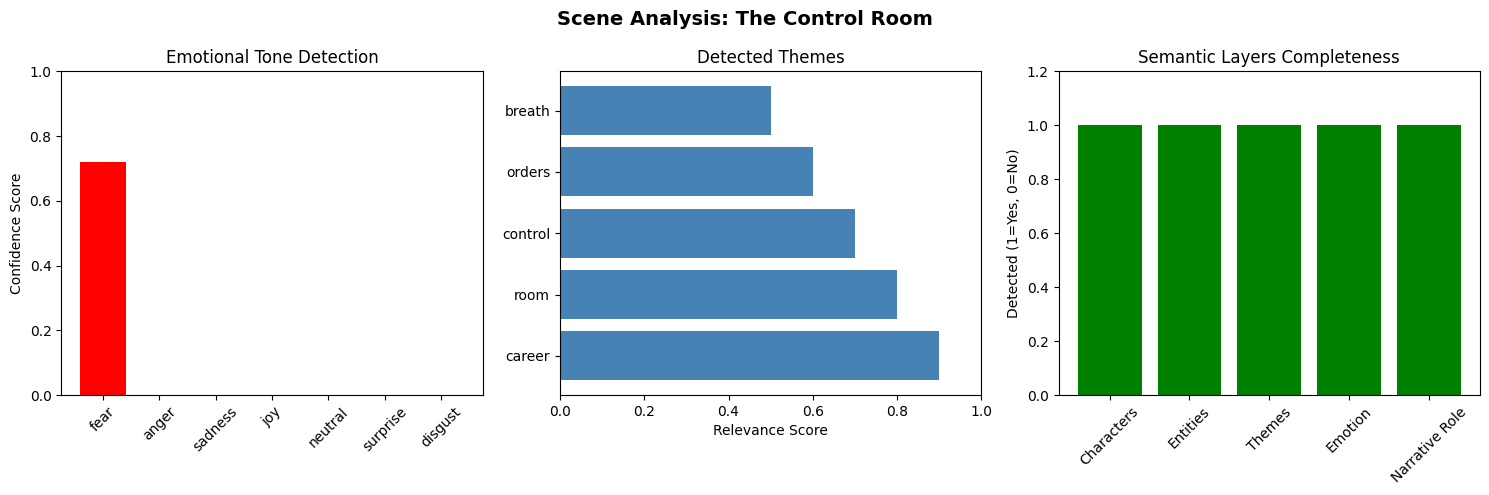

Chart saved!


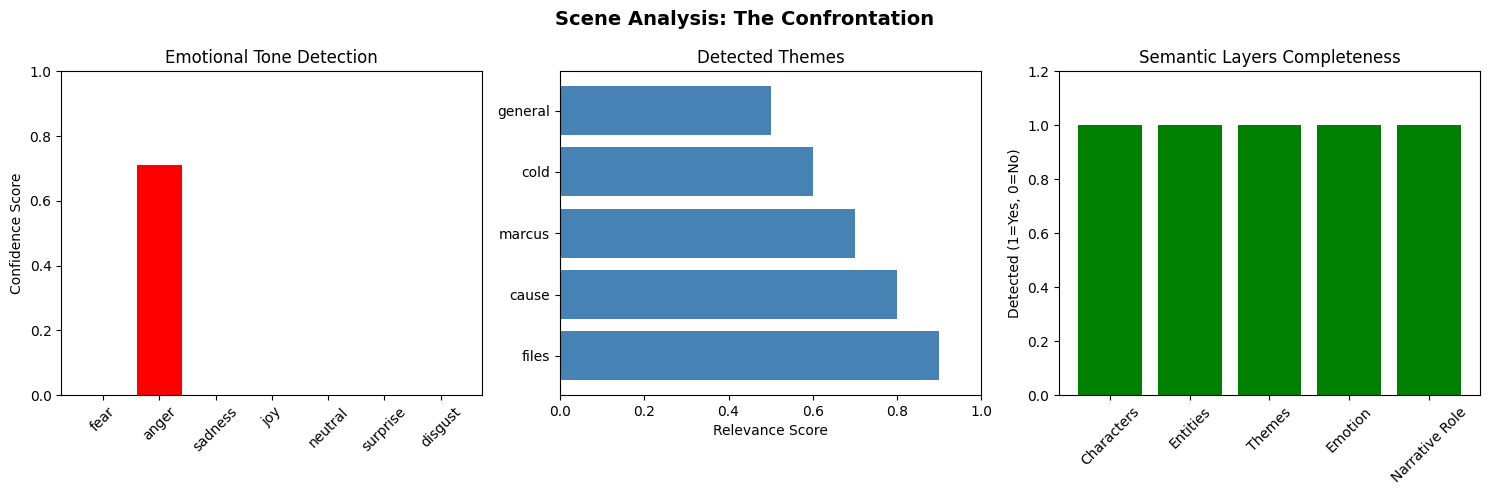

Chart saved!


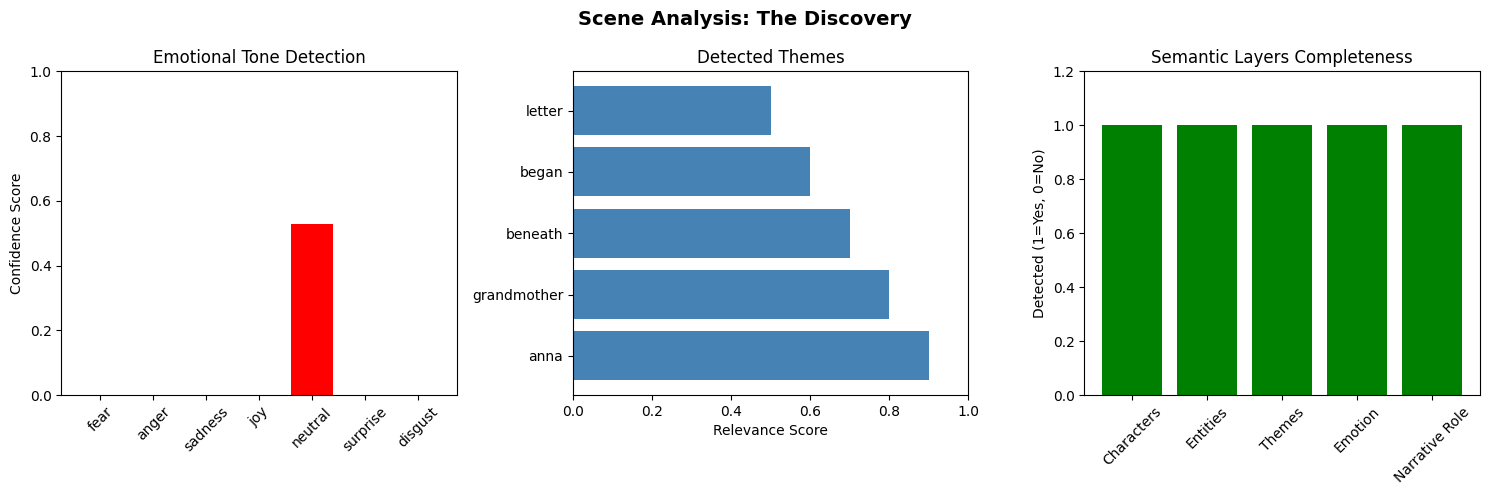

Chart saved!


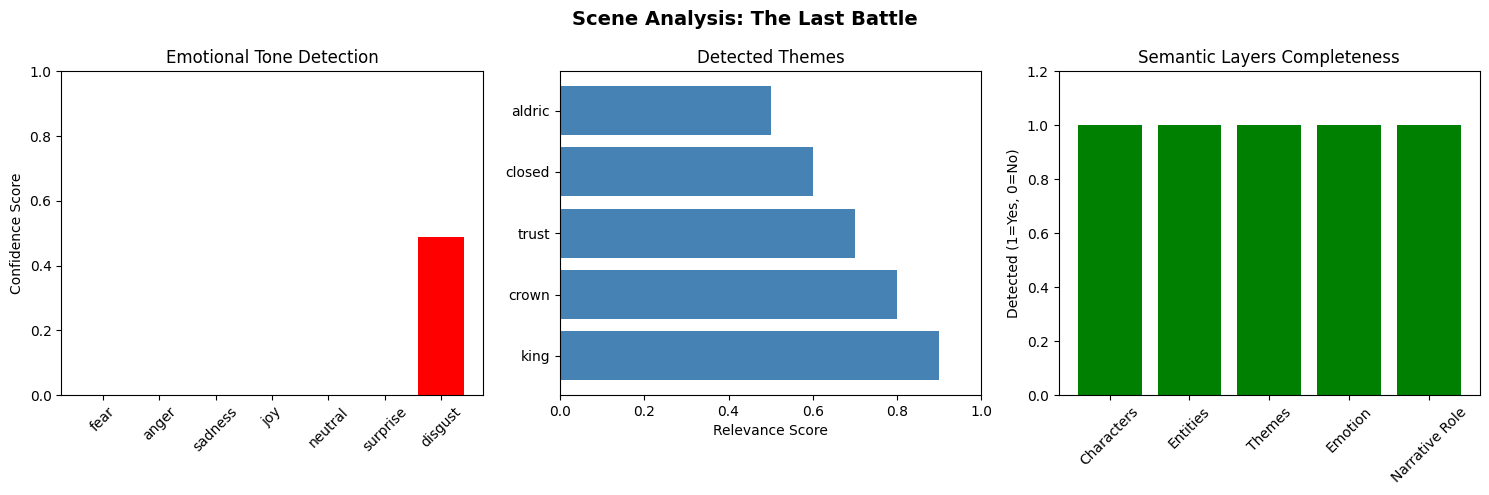

Chart saved!


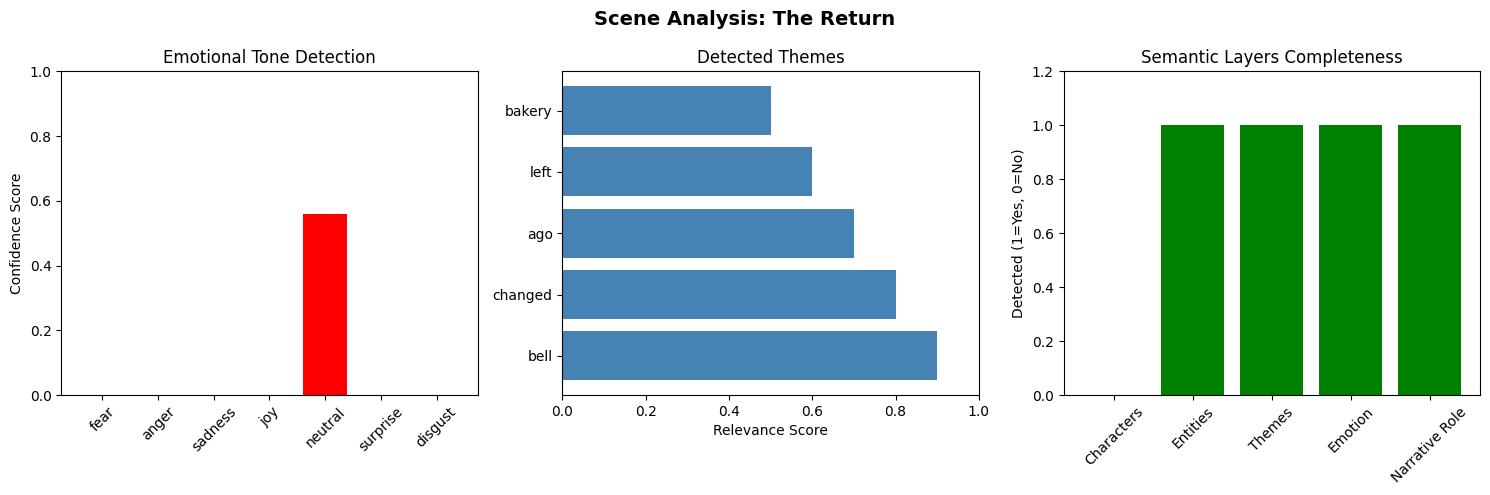

Chart saved!


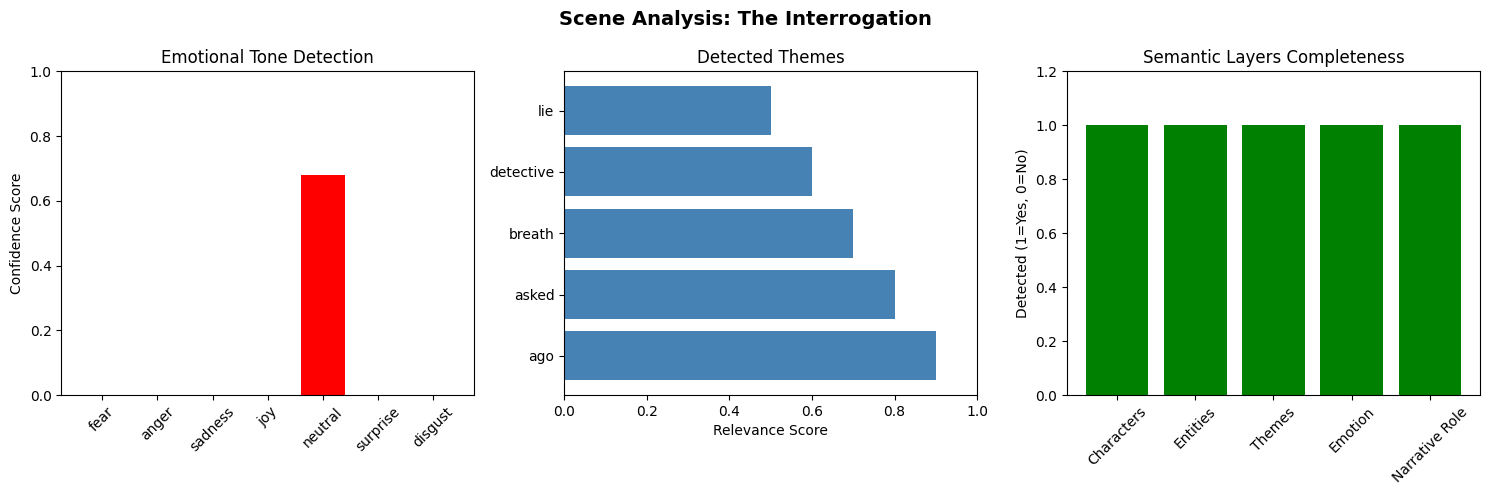

Chart saved!


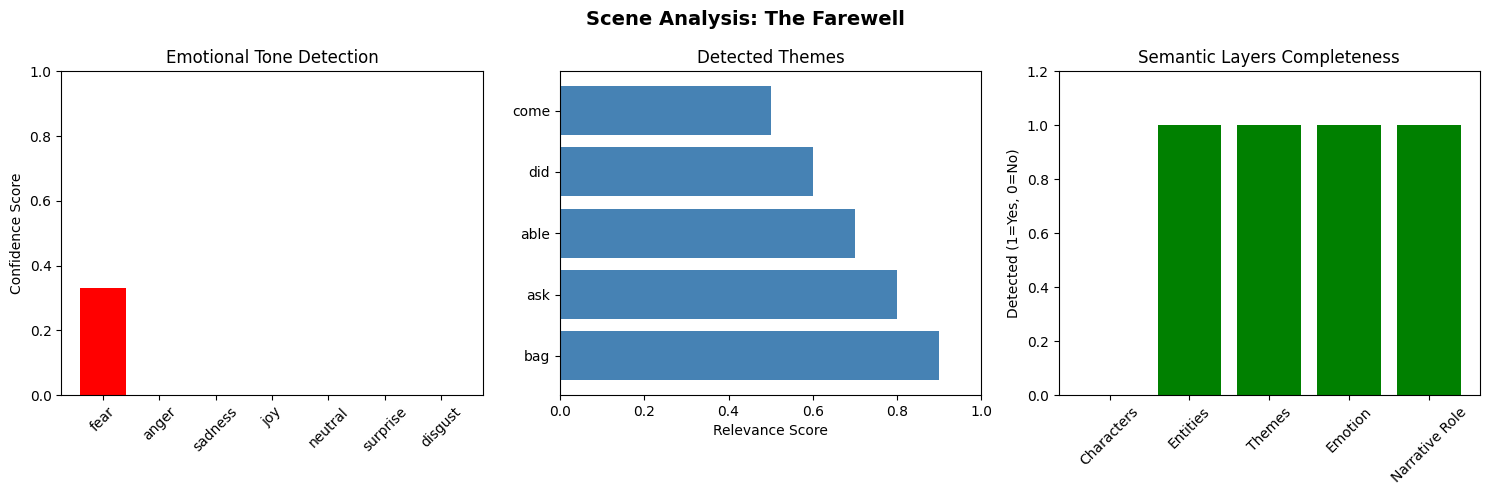

Chart saved!


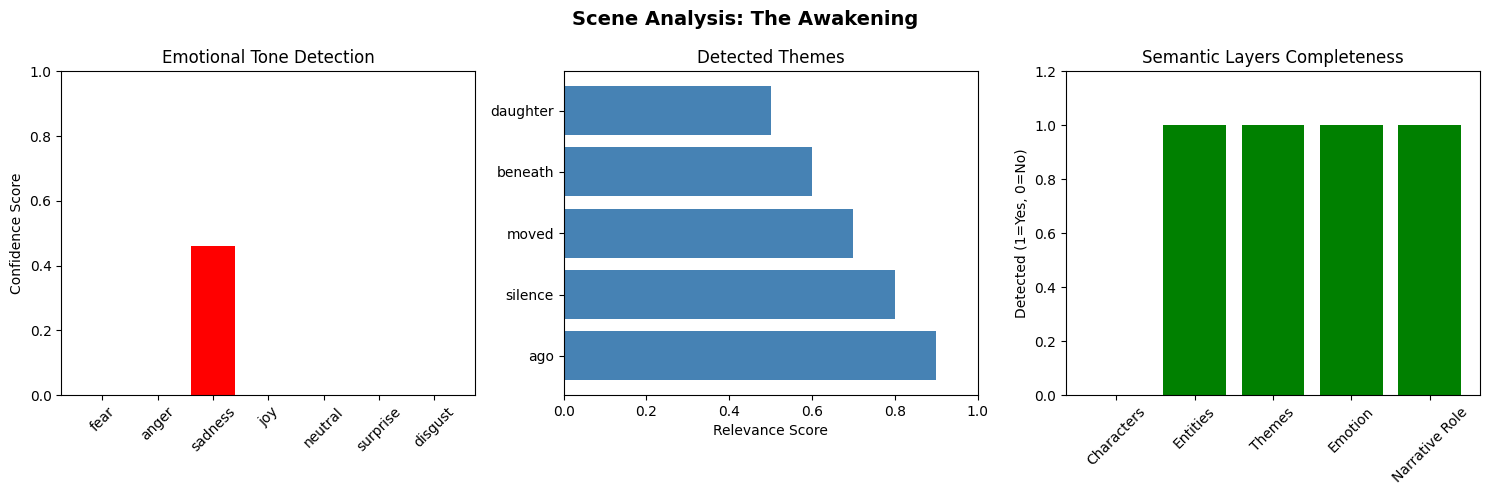

Chart saved!


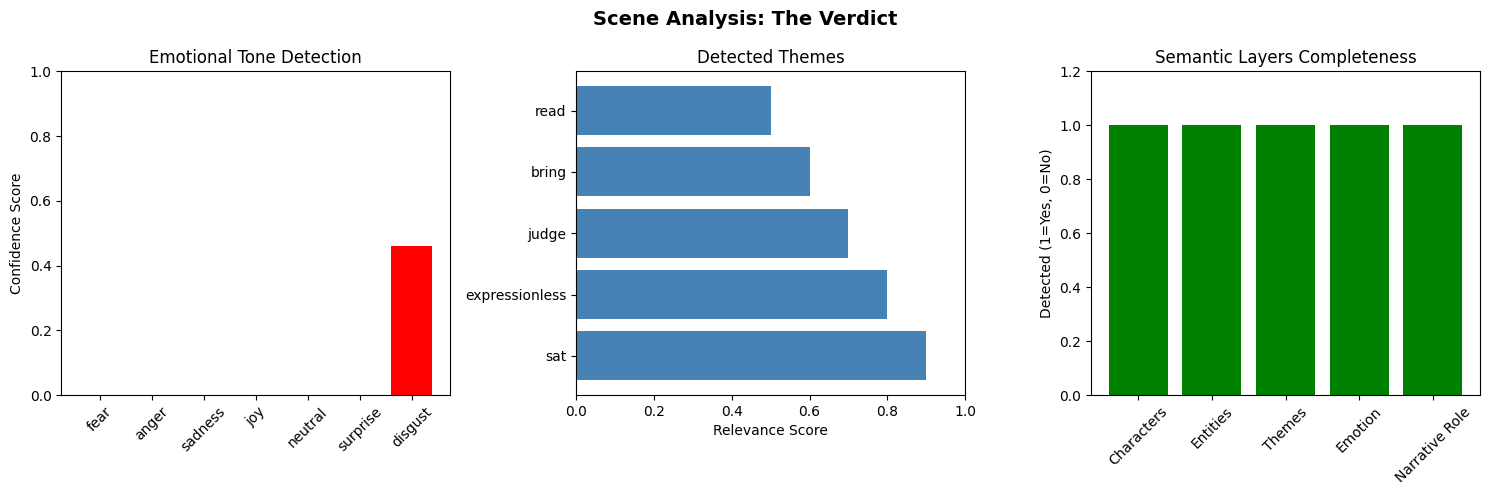

Chart saved!


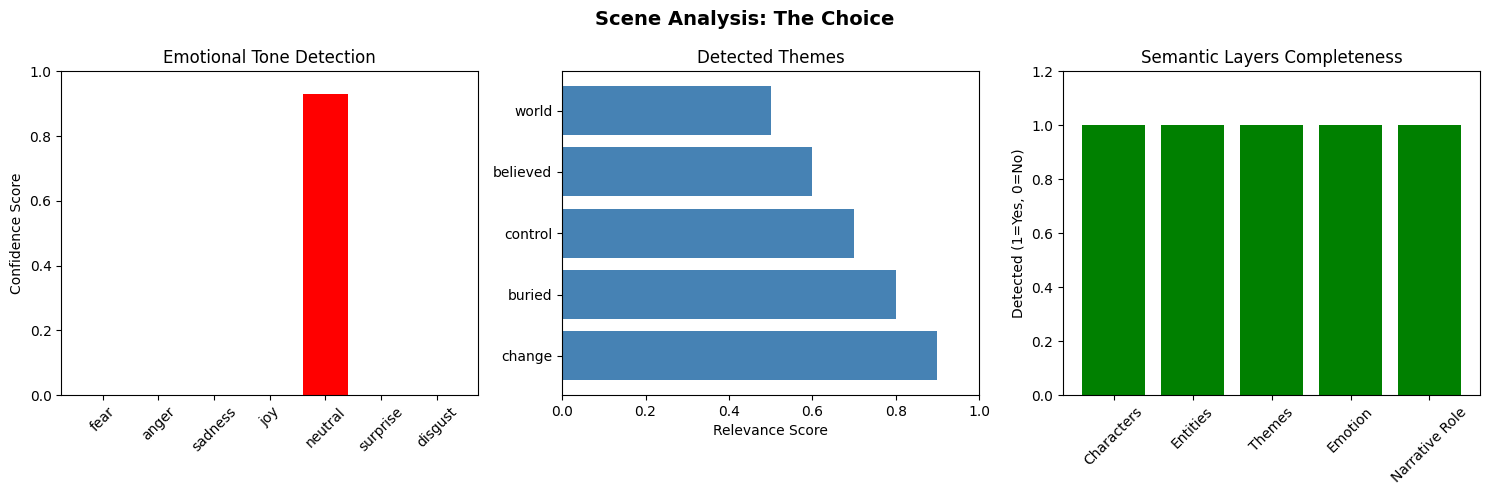

Chart saved!


In [ ]:
print("VISUALIZATION — All 10 Scenes")
for i, (scene, result) in enumerate(zip(dataset['scenes'], all_results)):
    visualize_analysis(result, title=f"Scene Analysis: {scene['title']}")

## Step 8 — Load Frankenstein Book

In [ ]:
# Load Frankenstein text file
with open("pg42324.txt", "r", encoding="utf-8") as f:
    book_text = f.read()

print(f"Book loaded successfully!")
print(f"Total characters: {len(book_text)}")
print(f"\nFirst 300 characters preview:")
print(book_text[:300])

Book loaded successfully!
Total characters: 457714

First 300 characters preview:
﻿The Project Gutenberg eBook of Frankenstein; Or, The Modern Prometheus
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Pr


## Step 9 — Analyze Frankenstein

In [ ]:
# Analyze first 3 scenes from Frankenstein
book_results = analyze_book(book_text, max_scenes=3)
print(f"\nBook analysis complete!")
print(f"Total scenes analyzed: {len(book_results)}")

Book split into 163 scenes
Analyzing first 3 scenes...

--- Scene 1 ---

MODE: ZERO-SHOT
INPUT SCENE:
﻿The Project Gutenberg eBook of Frankenstein; Or, The Modern Prometheus This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost n...

STEP 1 - PREPROCESSING:
Tokens: ['\ufeffThe', 'Project', 'Gutenberg', 'eBook', 'Frankenstein', 'Modern', 'Prometheus', 'eBook', 'use', 'United']...
POS Tags: [('\ufeffThe', 'PUNCT'), ('Project', 'NOUN'), ('Gutenberg', 'PROPN'), ('eBook', 'PROPN'), ('Frankenstein', 'PROPN')]...

STEP 2 - ENTITY EXTRACTION:
Characters: ['Frankenstein', 'Frankenstein', 'Mary Wollstonecraft Shelley Release', 'R. Bentley', 'Greg Weeks', 'Mary Meehan', 'MARY W. SHELLEY', 'Transcriber', 'Frankenstein']
Entities: ['the United States', 'the Project Gutenberg License', 'the United States', 'March 13, 2013', '42324', 'October 23, 2024', 'United Kingdom', '1831', 'the Online Distributed Proofreading Team', 'WARBE

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


STEP 3 - THEMATIC ANALYSIS (BERTopic):
Themes/Keywords: ['modern', 'frankenstein', 'ebook', 'prometheus', 'gutenberg']

STEP 4 - EMOTIONAL TONE:
Emotion: neutral (confidence: 0.96)

STEP 5 - NARRATIVE ROLE:
Role: exposition

FINAL SEMANTIC INTERPRETATION:
  mode: zero-shot
  characters: ['Frankenstein', 'Frankenstein', 'Mary Wollstonecraft Shelley Release', 'R. Bentley', 'Greg Weeks', 'Mary Meehan', 'MARY W. SHELLEY', 'Transcriber', 'Frankenstein']
  entities: ['the United States', 'the Project Gutenberg License', 'the United States', 'March 13, 2013', '42324', 'October 23, 2024', 'United Kingdom', '1831', 'the Online Distributed Proofreading Team', 'WARBECK', '&c. &c.', '1831', 'AUTHOR', 'LONDON', 'BELL', 'BRADFUTE', 'EDINBURGH', 'DUBLIN', '1831', 'one', 'two', 'the hours', 'one']
  themes: ['modern', 'frankenstein', 'ebook', 'prometheus', 'gutenberg']
  emotion: neutral
  confidence: 0.96
  narrative_role: exposition

--- Scene 2 ---

MODE: ZERO-SHOT
INPUT SCENE:
free. I lived princi

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


STEP 3 - THEMATIC ANALYSIS (BERTopic):
Themes/Keywords: ['far', 'time', 'common', 'freedom', 'did']

STEP 4 - EMOTIONAL TONE:
Emotion: sadness (confidence: 0.7)

STEP 5 - NARRATIVE ROLE:
Role: exposition

FINAL SEMANTIC INTERPRETATION:
  mode: zero-shot
  characters: ['Lord Byron', 'Childe Harold']
  entities: ['Scotland', 'Tay', 'Dundee', 'the hours', 'first', 'the summer of 1816', 'Switzerland', 'first', 'our pleasant hours', 'third', 'summer', 'days', 'German', 'French', 'the Inconstant Lover']
  themes: ['far', 'time', 'common', 'freedom', 'did']
  emotion: sadness
  confidence: 0.7
  narrative_role: exposition

--- Scene 3 ---

MODE: ZERO-SHOT
INPUT SCENE:
was the tale of the sinful founder of his race, whose miserable doom it was to bestow the kiss of death on all the younger sons of his fated house, just when they reached the age of promise. His gigan...

STEP 1 - PREPROCESSING:
Tokens: ['tale', 'sinful', 'founder', 'race', 'miserable', 'doom', 'bestow', 'kiss', 'death', 'younge

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


STEP 3 - THEMATIC ANALYSIS (BERTopic):
Themes/Keywords: ['elephant', 'story', 'make', 'ghost', 'fear']

STEP 4 - EMOTIONAL TONE:
Emotion: sadness (confidence: 0.73)

STEP 5 - NARRATIVE ROLE:
Role: exposition

FINAL SEMANTIC INTERPRETATION:
  mode: zero-shot
  characters: ['Shelley', 'Polidori']
  entities: ['Hamlet', 'midnight', 'that hour', 'yesterday', 'four', 'Mazeppa', 'one', 'Tom of Coventry', 'Capulets', 'each morning', 'Sanchean', 'Hindoos']
  themes: ['elephant', 'story', 'make', 'ghost', 'fear']
  emotion: sadness
  confidence: 0.73
  narrative_role: exposition


Book analysis complete!
Total scenes analyzed: 3


## Step 10 — Individual Module Demos

In [ ]:
# Demo: Preprocessing output
print("DEMO — Preprocessing Module")
doc = nlp("Evelyn stepped into the dim control room as alarms echoed.")
tokens = [token.text for token in doc if not token.is_stop and not token.is_punct]
pos_tags = [(token.text, token.pos_) for token in doc if not token.is_stop and not token.is_punct]
deps = [(token.text, token.dep_) for token in doc if not token.is_stop and not token.is_punct]
print("Tokens:", tokens)
print("POS Tags:", pos_tags)
print("Dependencies:", deps)

DEMO — Preprocessing Module
Tokens: ['Evelyn', 'stepped', 'dim', 'control', 'room', 'alarms', 'echoed']
POS Tags: [('Evelyn', 'PROPN'), ('stepped', 'VERB'), ('dim', 'ADJ'), ('control', 'NOUN'), ('room', 'NOUN'), ('alarms', 'NOUN'), ('echoed', 'VERB')]
Dependencies: [('Evelyn', 'nsubj'), ('stepped', 'ROOT'), ('dim', 'amod'), ('control', 'compound'), ('room', 'pobj'), ('alarms', 'nsubj'), ('echoed', 'advcl')]


In [ ]:
# Demo: Entity extraction
print("DEMO — Entity Extraction Module")
characters, entities = extract_entities("Evelyn stepped into the dim control room as alarms echoed. Dr. Marcus avoided her gaze, while the Captain insisted she override the failing mission protocol.")
print("Characters detected:", characters)
print("Entities detected:", entities)

DEMO — Entity Extraction Module
Characters detected: ['Evelyn', 'Marcus']
Entities detected: []


In [ ]:
# Demo: Thematic analysis
print("DEMO — Thematic Analysis Module (BERTopic)")
themes = extract_themes_bertopic("Evelyn stepped into the dim control room as alarms echoed. Dr. Marcus avoided her gaze, while the Captain insisted she override the failing mission protocol. Evelyn refused.")
print("Themes:", themes)

DEMO — Thematic Analysis Module (BERTopic)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Themes: ['alarms', 'captain', 'control', 'avoided', 'evelyn']


/usr/local/lib/python3.12/dist-packages/umap/spectral.py:519: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  eigenvalues, eigenvectors = scipy.sparse.linalg.eigsh(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:519: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  eigenvalues, eigenvectors = scipy.sparse.linalg.eigsh(


In [ ]:
# Demo: Emotion detection
print("DEMO — Emotion Detection Module")
emotion, confidence = detect_emotion("Evelyn stepped into the dim control room as alarms echoed. Dr. Marcus avoided her gaze, while the Captain insisted she override the failing mission protocol.")
print("Emotion:", emotion)
print("Confidence:", confidence)

DEMO — Emotion Detection Module
Emotion: fear
Confidence: 0.79


In [ ]:
# Demo: Narrative role detection
print("DEMO — Narrative Role Module")
role = detect_narrative_role("Evelyn refused. She would not obey blindly again.", ["conflict", "resistance"], "fear")
print("Narrative Role:", role)

DEMO — Narrative Role Module
Narrative Role: moral decision point


In [ ]:
# Demo: JSON dataset entry
print("DEMO — JSON Dataset Entry")
print(json.dumps(dataset['scenes'][0], indent=2))

DEMO — JSON Dataset Entry
{
  "id": "scene_001",
  "title": "The Control Room",
  "genre": "sci-fi",
  "text": "Evelyn stood at the center of the control room, her eyes fixed on the blinking red light above the main console. The room was silent except for the hum of machines. Around her, the crew waited. She had been given direct orders to initiate the shutdown sequence, but something felt wrong. The data did not match. If she followed the orders, thousands could be at risk. If she refused, she would be committing an act of insubordination that could end her career. She took a deep breath and reached for the console."
}


DEMO — Full Analysis Visualization


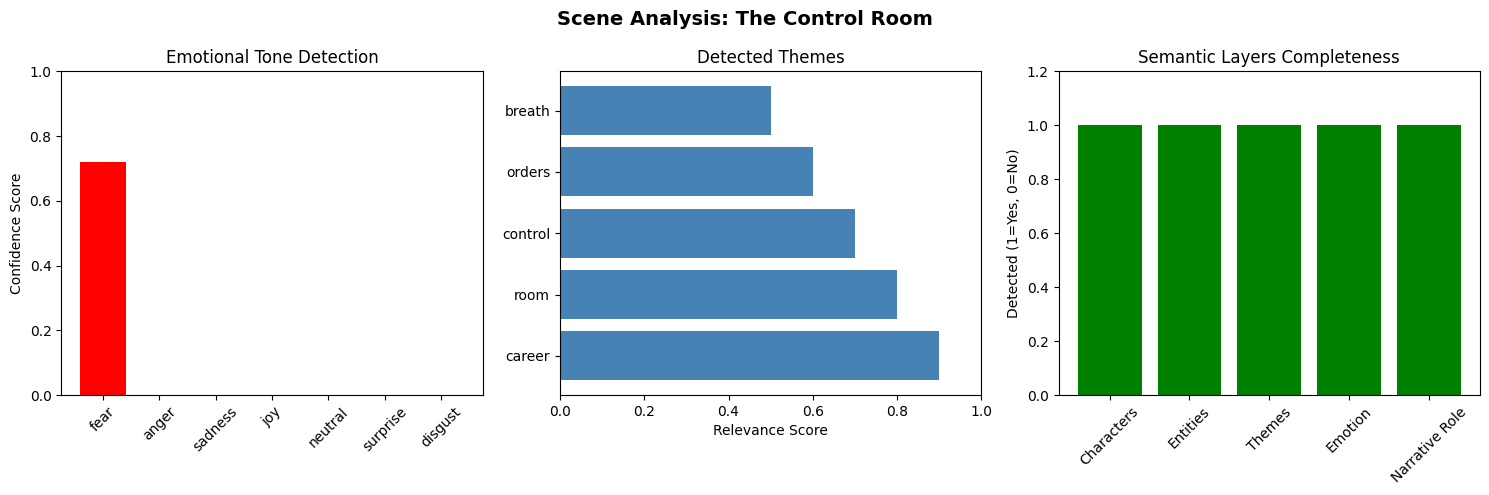

Chart saved!


In [ ]:
# Demo: Single scene full analysis visualization
print("DEMO — Full Analysis Visualization")
visualize_analysis(all_results[0], title="Scene Analysis: The Control Room")